In [221]:
import numpy as np
import json
from sentence_transformers import SentenceTransformer
import pickle
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from statistics import mean
from seaborn import heatmap

In [3]:
model = SentenceTransformer('multi-qa-mpnet-base-cos-v1')

In [173]:
data = []
with open('data/patent_sample_100.json') as fil:
    for line in fil:
        data.append(json.loads(line))

In [174]:
count = 0
for item in data:
    item['encoding'] = model.encode(item['title_abstract'])
    count += 1
    if count%100 == 0:
        print(count)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500


In [30]:
# pickle.dump(data, open('data/patent_sample_100.pckl', 'wb'))
data = pickle.load(open('data/patent_sample_1000.pckl','rb'))

In [31]:
data_matrix = np.array([item['encoding'] for item in data])

In [126]:
data_matrix.shape

(11658, 768)

In [32]:
overlap = np.dot(data_matrix,data_matrix.T)

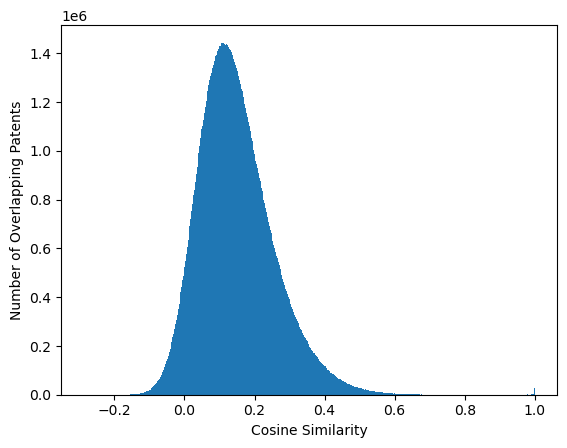

In [208]:
plt.hist(np.ndarray.flatten(overlap), bins=500)
plt.ylabel('Number of Overlapping Patents')
plt.xlabel('Cosine Similarity')
plt.show()

In [37]:
pca = PCA(n_components=5)

In [38]:
pca_data = pca.fit_transform(data_matrix)

In [123]:
def cat_to_color(cat):
    if cat == 'biotechnology':
        return 'C0'
    if cat == 'telecommunications':
        return 'C1'
    if cat == 'food_and_tobacco':
        return 'C2'
    if cat == 'mining_and_quarrying':
        return 'C3'
    if cat == 'real_estate':
        return 'C4'
    return 'C5'

In [124]:
clist = [cat_to_color(item['category']) for item in data]
axislist = ['PC 1', 'PC 2', 'PC 3', 'PC 4', 'PC 5']

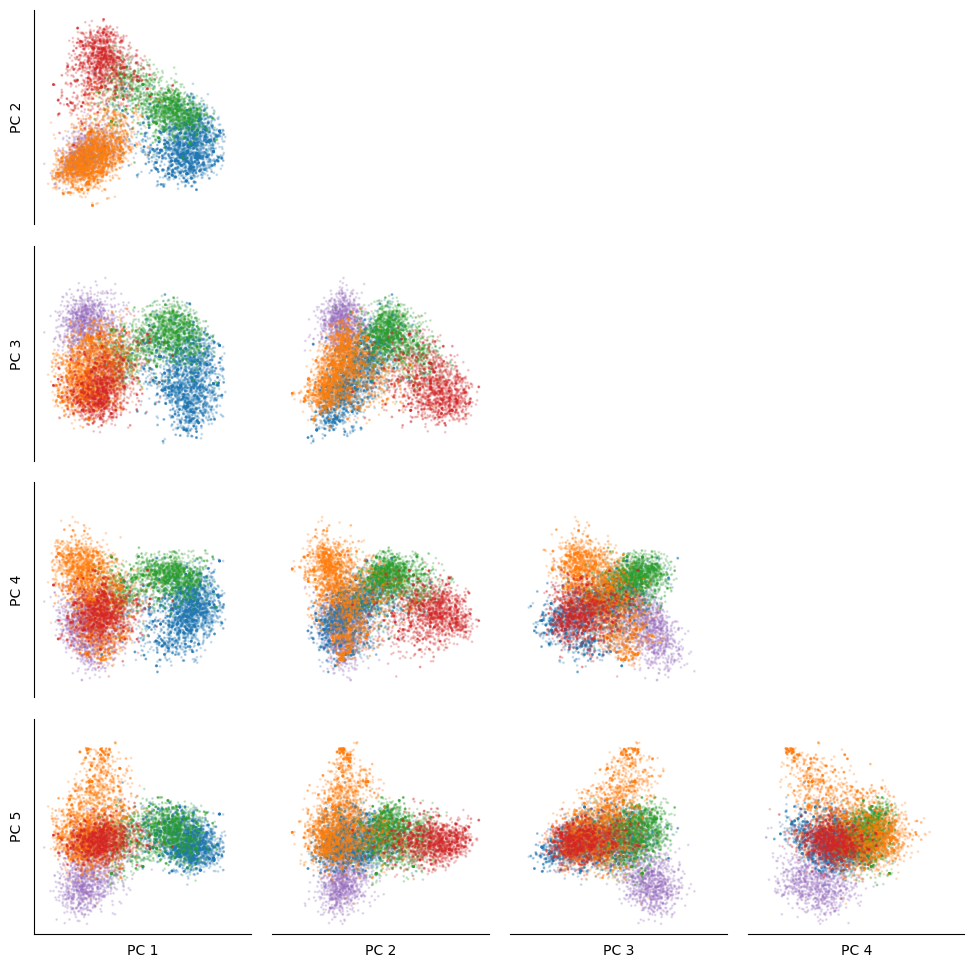

In [166]:
fig = plt.figure(figsize=(12,12))
gs = fig.add_gridspec(4,4, hspace=0.1, wspace=0.1)
axs = gs.subplots(sharex=True, sharey=True)
for i in range(4):
    for j in range(i,4):
        axs[j][i].scatter(pca_data[:,i],pca_data[:,j+1],c=clist,s=1, alpha = 0.2)
        axs[j][i].set_yticks([])
        axs[j][i].set_xticks([])
        axs[i][j].axis('off')
        axs[j][i].axis('off')
        axs[3][i].axis('on')
        axs[3][i].spines[['top','right','bottom','left']].set_visible(False)
        axs[j][0].axis('on')
        axs[j][0].spines[['top','right','bottom','left']].set_visible(False)
        axs[3][i].set_xlabel(axislist[i])
        axs[3][i].spines['bottom'].set_visible(True)
        axs[j][0].set_ylabel(axislist[j+1])
        axs[j][0].spines['left'].set_visible(True)
axs[3][0].spines[['bottom']].set_visible(True)
plt.show()

In [110]:
U,S,Vt = np.linalg.svd(data_matrix)

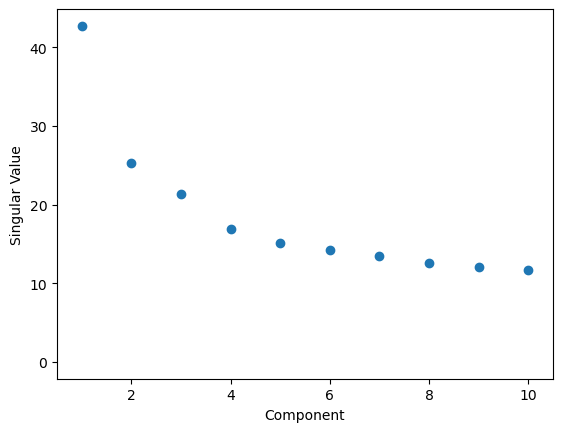

In [122]:
plt.scatter(range(1,len(S)+1),S)
plt.xlim([0.5,10.5])
plt.ylabel('Singular Value')
plt.xlabel('Component')
plt.show()

In [167]:
families = {}
for item in data:
    family_id = item['family_id']
    try:
        families[family_id].append(item['encoding'])
    except KeyError:
        families[family_id] = [item['encoding']]

In [200]:
avg_cos = []
for key in families.keys():
    n_patents = len(families[key])
    if n_patents > 1:
        mat_temp = np.array(families[key])
        overlap_temp = np.dot(mat_temp,mat_temp.T)
        avg_cos.append(mean([overlap_temp[i][j] for i in range(n_patents) for j in range(i+1,n_patents)]))

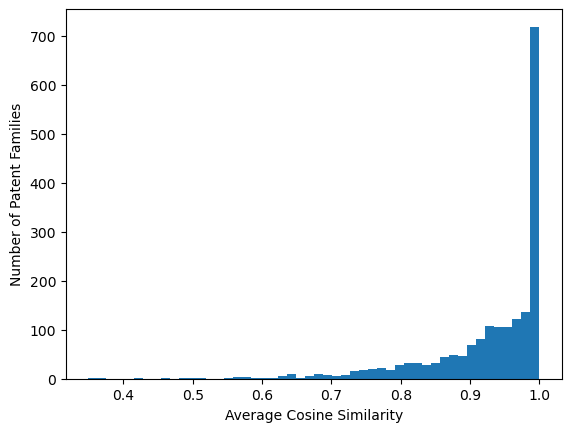

In [206]:
plt.hist(avg_cos,bins=50)
plt.ylabel('Number of Patent Families')
plt.xlabel('Average Cosine Similarity')
plt.show()

In [209]:
categories = {}
for item in data:
    category = item['category']
    try:
        categories[category].append(item['encoding'])
    except KeyError:
        categories[category] = [item['encoding']]

In [211]:
categories.keys()

dict_keys(['real_estate', 'biotechnology', 'food_and_tobacco', 'telecommunications', 'mining_and_quarrying'])

In [219]:
keylist = ['biotechnology','telecommunications','food_and_tobacco','mining_and_quarrying','real_estate']
avg_categories = {}
for key1 in keylist:
    for key2 in keylist:
        data1 = np.array(categories[key1])
        data2 = np.array(categories[key2])
        overlap_temp = np.dot(data1,data2.T)
        avg_categories[(key1,key2)] = mean(np.ndarray.flatten(overlap_temp))

In [220]:
avg_categories

{('biotechnology', 'biotechnology'): 0.22487079,
 ('biotechnology', 'telecommunications'): 0.10514556,
 ('biotechnology', 'food_and_tobacco'): 0.14091913,
 ('biotechnology', 'mining_and_quarrying'): 0.085056946,
 ('biotechnology', 'real_estate'): 0.09836937,
 ('telecommunications', 'biotechnology'): 0.10514556,
 ('telecommunications', 'telecommunications'): 0.24030685,
 ('telecommunications', 'food_and_tobacco'): 0.102252424,
 ('telecommunications', 'mining_and_quarrying'): 0.14252906,
 ('telecommunications', 'real_estate'): 0.2039199,
 ('food_and_tobacco', 'biotechnology'): 0.14091913,
 ('food_and_tobacco', 'telecommunications'): 0.102252424,
 ('food_and_tobacco', 'food_and_tobacco'): 0.20552906,
 ('food_and_tobacco', 'mining_and_quarrying'): 0.12739246,
 ('food_and_tobacco', 'real_estate'): 0.11098675,
 ('mining_and_quarrying', 'biotechnology'): 0.085056946,
 ('mining_and_quarrying', 'telecommunications'): 0.14252906,
 ('mining_and_quarrying', 'food_and_tobacco'): 0.12739246,
 ('mini

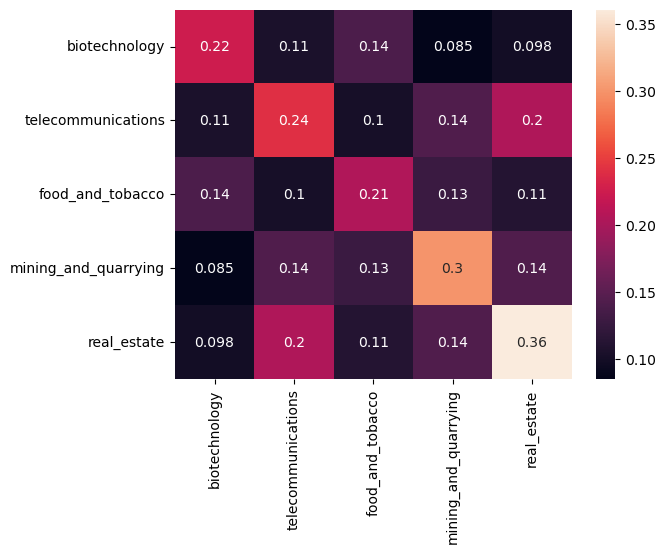

In [243]:
heatmap([[avg_categories[(key1,key2)] for key1 in keylist] for key2 in keylist],
       xticklabels=keylist, yticklabels=keylist, annot=True)
plt.show()

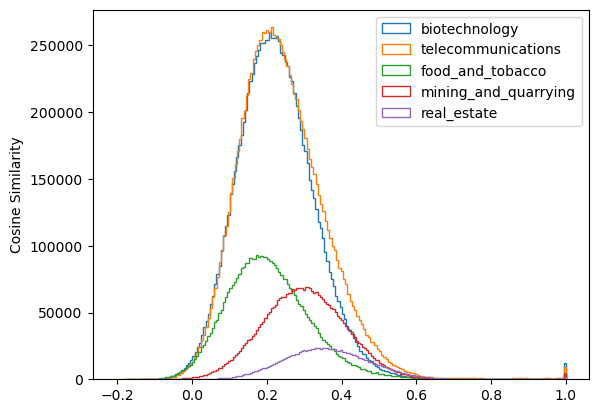

In [242]:
for key in keylist:
    mat_temp = np.array(categories[key])
    overlap_temp = np.dot(mat_temp,mat_temp.T)
    plt.hist(np.ndarray.flatten(overlap_temp),bins=200,label=key, histtype='step')
plt.ylabel('Number of overlapping patents')
plt.ylabel('Cosine Similarity')
plt.legend()
plt.show()